# L2 · Notebook 03 — 行动价值 $q^\pi(s,a)$

## 教学目标

1. 计算行动价值
$$q^\pi(s,a) = r(s,a) + \gamma \sum_{s'} P(s'|s,a)\, v^\pi(s')$$
2. 验证 $v$ 与 $q$ 的关系：$v^\pi(s) = \sum_a \pi(a|s)\, q^\pi(s,a)$
3. 用 $q^\pi$ 解读：在 $s$ 处该选哪个 $a$ 最好（贪婪改进，铺垫 L3）

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from shared.grid_world import GridWorld
from shared.plotting import plot_value_heatmap, plot_policy_arrows, setup_chinese_font

setup_chinese_font()
env = GridWorld()
ACTIONS = env.actions  # ['up', 'down', 'left', 'right', 'stay']
_, policy_star, _ = env.value_iteration()
v_pi = env.solve_bellman(policy_star)
print('|S| × |A| =', env.n_states, '×', env.n_actions)

|S| × |A| = 25 × 5


## 1. 计算 Q 表 (|S|, |A|)

In [2]:
Q = env.compute_q_table(v_pi)
print('Q shape:', Q.shape)
print('Q[s1, ·]:')
for ai, a in enumerate(ACTIONS):
    print(f'  q^π(s1, {a:>5}) = {Q[0, ai]:+.4f}')
print(f'\n→ argmax_a q^π(s1, a) = {ACTIONS[Q[0].argmax()]}  (与最优策略 π*[s1]={policy_star[(0,0)]} 一致)')

Q shape: (25, 5)
Q[s1, ·]:
  q^π(s1,    up) = -0.5217
  q^π(s1,  down) = +0.5314
  q^π(s1,  left) = -0.5217
  q^π(s1, right) = +0.4305
  q^π(s1,  stay) = +0.4783

→ argmax_a q^π(s1, a) = down  (与最优策略 π*[s1]=down 一致)


## 2. 验证 $v(s) = \sum_a \pi(a|s)\, q(s,a)$

我们的 π 是确定性策略（独热）：$\pi(a^*|s)=1$，其它为 0。所以 $v(s) = q(s, a^*)$。

In [3]:
v_from_q = np.zeros(env.n_states)
for s in env.all_states():
    i = env.state_index(s)
    a_star = policy_star[s]
    ai = ACTIONS.index(a_star)
    v_from_q[i] = Q[i, ai]

print(f'||v^π - max_a Q^π(·, a)||_∞ = {np.max(np.abs(v_pi - v_from_q)):.2e}')
print('  (确定性最优策略下 v(s) = max_a q(s, a))')

||v^π - max_a Q^π(·, a)||_∞ = 1.11e-16
  (确定性最优策略下 v(s) = max_a q(s, a))


## 3. 随机策略下验证（让 π 真的混合多个动作）

In [4]:
# 软策略：每个状态等概率混合 4 个移动动作 (不含 stay)
rng = np.random.default_rng(0)
n, A = env.n_states, env.n_actions
Pi = np.zeros((n, A))
for s in env.all_states():
    i = env.state_index(s)
    for ai in range(4):  # up/down/left/right
        Pi[i, ai] = 0.25

# 这是随机策略，需要支持随机 P^π → 我们对每个动作期望
# v(s) = sum_a π(a|s) [r(s,a) + γ sum_s' P(s'|s,a) v(s')]
# 用迭代法解
v_soft = np.zeros(n)
for _ in range(1000):
    Q_soft = env.compute_q_table(v_soft)
    v_new = (Pi * Q_soft).sum(axis=1)
    if np.max(np.abs(v_new - v_soft)) < 1e-12:
        break
    v_soft = v_new

Q_soft = env.compute_q_table(v_soft)
v_check = (Pi * Q_soft).sum(axis=1)
print(f'软策略下 ||v - sum_a π(a|s) q(s,a)||_∞ = {np.max(np.abs(v_soft - v_check)):.2e}')
print(f'v^π_soft[s1] = {v_soft[0]:+.4f}  (远低于最优 {v_pi[0]:+.4f})')

软策略下 ||v - sum_a π(a|s) q(s,a)||_∞ = 9.25e-13
v^π_soft[s1] = -3.9574  (远低于最优 +0.5314)


## 4. 可视化 Q 表（25×5 热图）

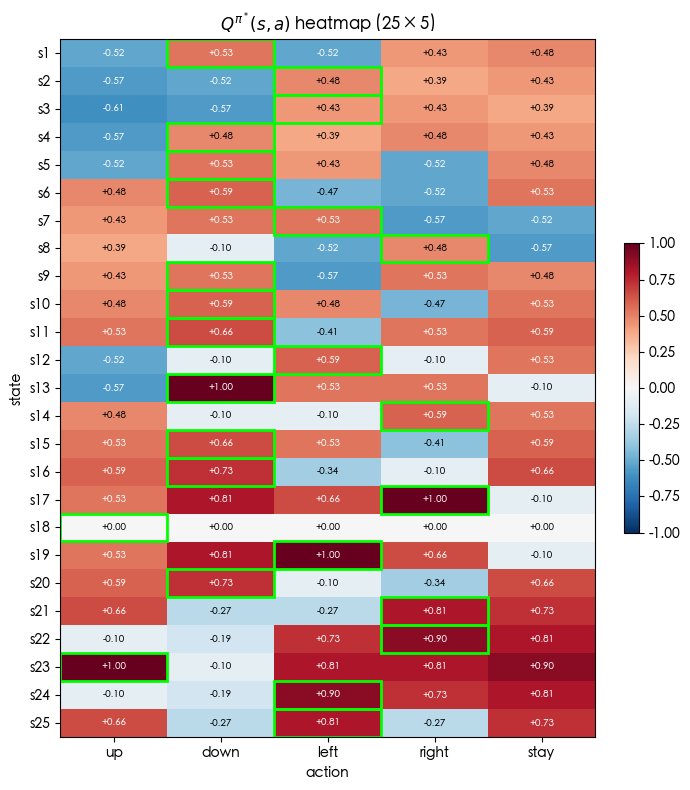

In [5]:
fig, ax = plt.subplots(figsize=(7, 8))
im = ax.imshow(Q, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(len(ACTIONS)))
ax.set_xticklabels(ACTIONS)
ax.set_yticks(range(env.n_states))
ax.set_yticklabels([f's{i+1}' for i in range(env.n_states)])
ax.set_xlabel('action')
ax.set_ylabel('state')
ax.set_title('$Q^{\\pi^*}(s, a)$ heatmap (25 × 5)')
for i in range(env.n_states):
    for j in range(env.n_actions):
        ax.text(j, i, f'{Q[i, j]:+.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(Q[i, j]) > 0.5 else 'black')
    # 标记 argmax
    j_star = Q[i].argmax()
    ax.add_patch(plt.Rectangle((j_star - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='lime', linewidth=2))
plt.colorbar(im, ax=ax, fraction=0.025)
plt.tight_layout()
plt.savefig('figures/q_table_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

**观察**：每行的绿框 = argmax_a q(s,a) = π*(s)。这就是 L3 "贪婪策略"的来源。

## 5. v 与 max-Q 并列热图

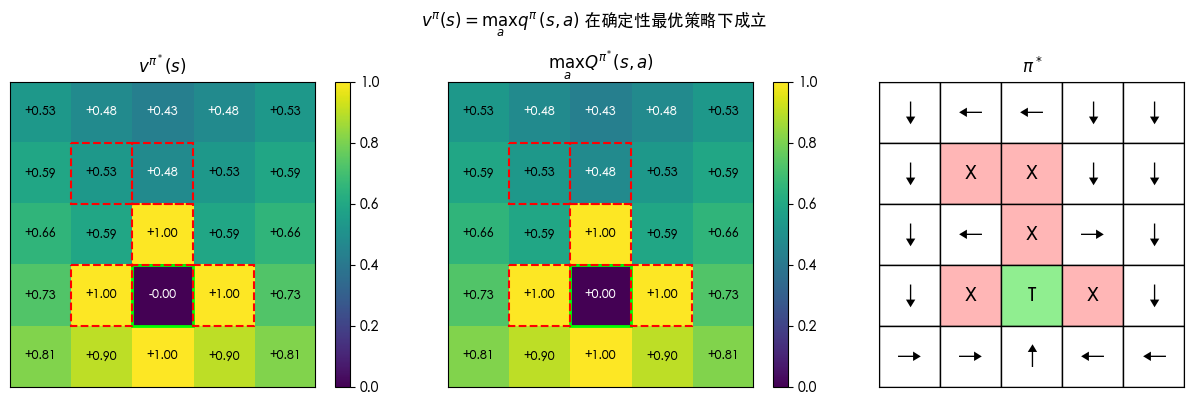

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_value_heatmap(env, v_pi, ax=axes[0], title='$v^{\\pi^*}(s)$')
plot_value_heatmap(env, Q.max(axis=1), ax=axes[1], title='$\\max_a Q^{\\pi^*}(s, a)$')
plot_policy_arrows(env, policy_star, ax=axes[2], title='$\\pi^*$')
fig.suptitle('$v^\\pi(s) = \\max_a q^\\pi(s,a)$ 在确定性最优策略下成立')
plt.tight_layout()
plt.savefig('figures/v_vs_maxq.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. 课堂诊断小结

| 论断 | 数值 |
|---|---|
| Q 表形状 | (25, 5) |
| 确定性 π 下 v=Q[·, π(·)] | 残差 < 1e-12 |
| 软策略下 v = E_a Q | 残差 < 1e-12 |
| argmax Q 给出贪婪策略 | 与 VI 输出一致 |

## 思考题

1. 为什么实际算法（Q-learning）学的是 $Q$ 而不是 $V$？（提示：要决策必须知道每个 a 的价值；只有 V 还要再算 max）
2. 如果策略 π 是"epsilon-soft"（每个动作概率至少 ε），$v^\pi(s)$ 与 $\max_a Q^\pi(s,a)$ 还相等吗？
3. 看上面 25×5 的 Q 表：哪些行最一致 (5 个 a 的 Q 值差不多)，哪些行最分裂？这反映了什么？